1:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import cufflinks as cf
import plotly.offline as plyo

raw = pd.read_csv("source/Chap_7/fxcm_eur_usd_eod_data.csv",
                  index_col=0, parse_dates=True)
quotes = raw[['AskOpen','AskHigh','AskLow','AskClose']]
quotes = quotes.iloc[-60:]

quotes.tail()

,AskOpen,AskHigh,AskLow,AskClose
2017-12-25 22:00:00,1.18667,1.18791,1.18467,1.18587
2017-12-26 22:00:00,1.18587,1.19104,1.18552,1.18885
2017-12-27 22:00:00,1.18885,1.19592,1.18885,1.19426
2017-12-28 22:00:00,1.19426,1.20256,1.19369,1.20092
2017-12-31 22:00:00,1.20092,1.20144,1.19994,1.20144


In [2]:
import plotly.graph_objs._figure as gofig

if not hasattr(gofig.Figure, "_patched"):
    _original_init = gofig.Figure.__init__

    def patched_init(self, *args, **kwargs):
        kwargs["skip_invalid"] = True
        _original_init(self, *args, **kwargs)

    gofig.Figure.__init__ = patched_init
    gofig.Figure._patched = True

In [3]:
qf = cf.QuantFig(
    quotes,
    title='EUR/USD Exchange Rate',
    legend='top',
    name='EUR/USD'
)
plyo.iplot(
    qf.iplot(asFigure=True),
    image='png',
    filename='qf_01'
)
plt.show()

2:

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

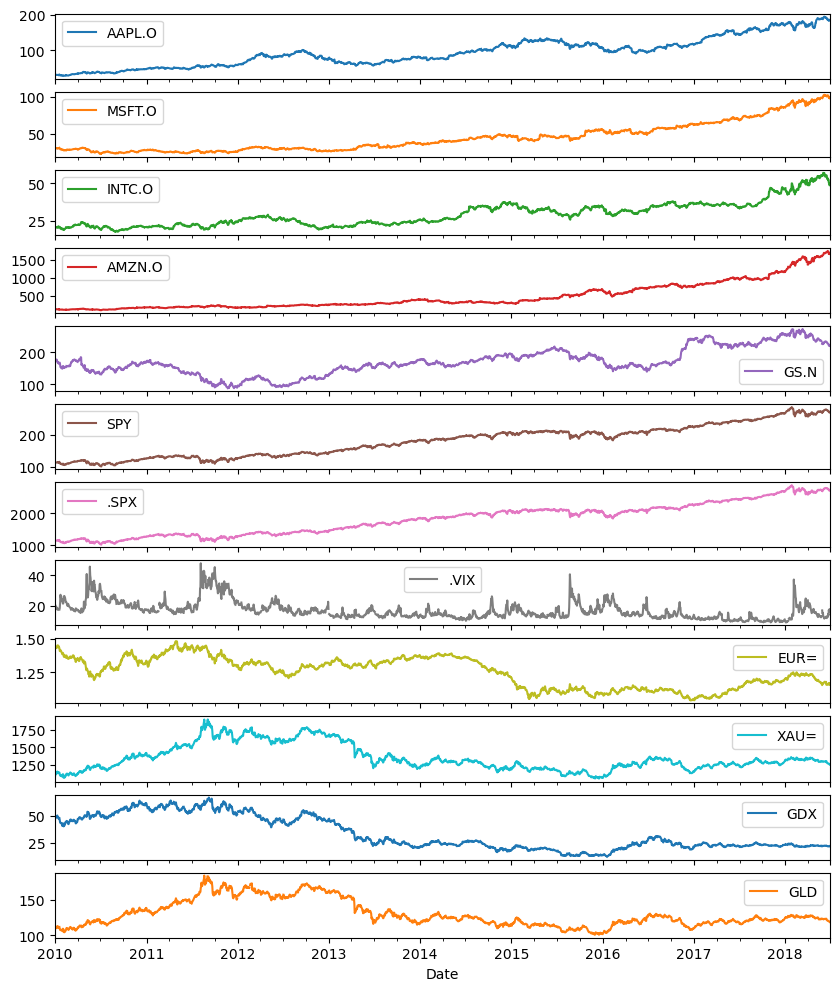

In [5]:
import numpy as np
import pandas as pd
from pylab import mpl, plt

filename = 'source/Chap_7/tr_eikon_eod_data.csv'
data = pd.read_csv(filename,index_col=0,parse_dates=True)

data.plot(figsize=(10,12), subplots=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23272\27243631.py:1: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



<Axes: >

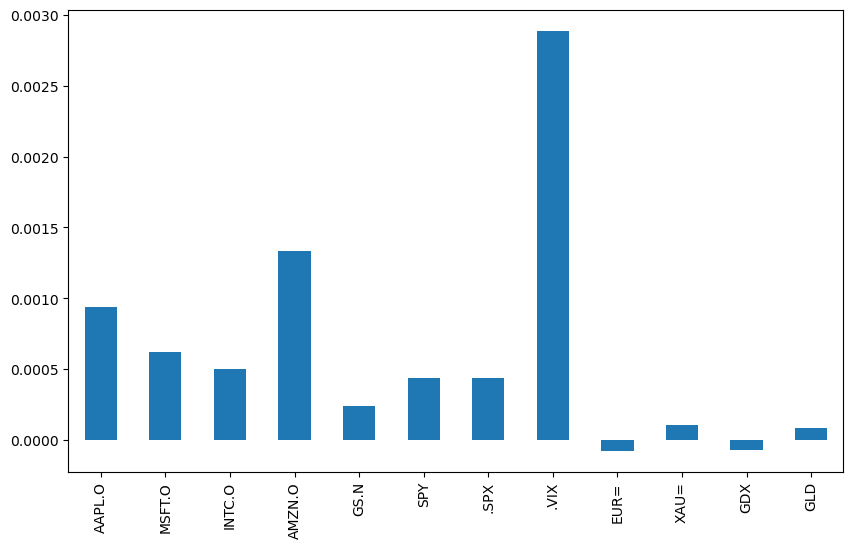

In [6]:
data.pct_change().mean().plot(kind='bar',figsize=(10,6))

In [8]:
rets = np.log(data / data.shift(1))
rets.head().round(3)

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006,0.021,NaN,NaN
2010-01-05,0.002,0.000,-0.000,0.006,0.018,0.003,0.003,-0.035,-0.003,-0.001,0.010,-0.001
2010-01-06,-0.016,-0.006,-0.003,-0.018,-0.011,0.001,0.001,-0.010,0.003,0.018,0.024,0.016
2010-01-07,-0.002,-0.010,-0.010,-0.017,0.019,0.004,0.004,-0.005,-0.007,-0.006,-0.005,-0.006


<Axes: xlabel='Date'>

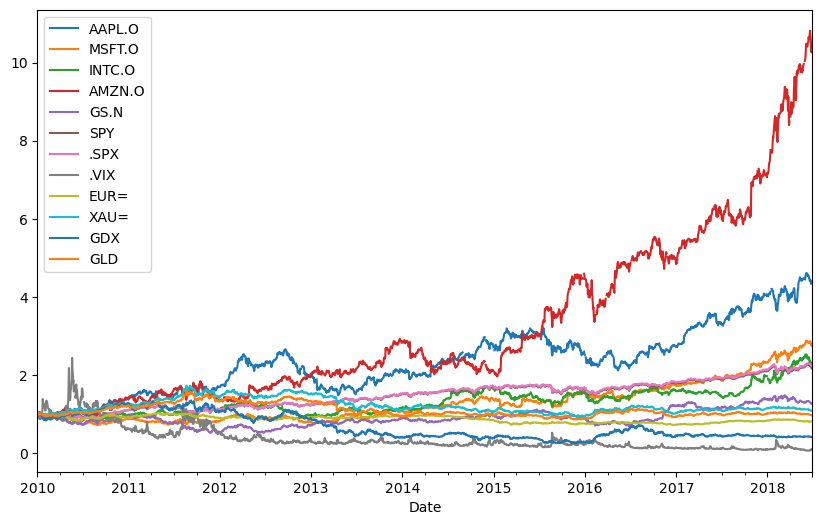

In [9]:
rets.cumsum().apply(np.exp).plot(figsize=(10,6))

In [10]:
sym = 'AAPL.O'
data = pd.DataFrame(data[sym].dropna())
data.tail()

,AAPL.O
Date,
2018-06-25,182.17
2018-06-26,184.43
2018-06-27,184.16
2018-06-28,185.50
2018-06-29,185.11


In [11]:
window = 20
data['min'] = data[sym].rolling(window).min()
data['mean'] = data[sym].rolling(window).mean()
data['max'] = data[sym].rolling(window).max()
data.dropna().head()

,AAPL.O,min,mean,max
Date,,,,
2010-02-01,27.818544,27.437544,29.580892,30.719969
2010-02-02,27.979972,27.437544,29.451249,30.719969
2010-02-03,28.461400,27.437544,29.343035,30.719969
2010-02-04,27.435687,27.435687,29.207892,30.719969
2010-02-05,27.922829,27.435687,29.099892,30.719969


<Axes: xlabel='Date'>

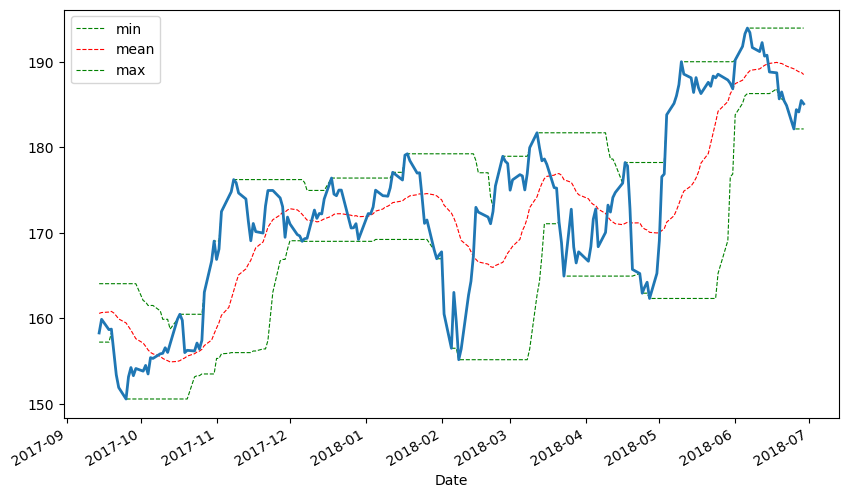

In [14]:
ax = data[['min','mean','max']]\
    .iloc[-200:].plot(figsize=(10,6),
                      style=['g--','r--','g--'],
                      lw=0.8)
data[sym].iloc[-200:].plot(ax=ax, lw=2.0)

In [15]:
data['SMA1'] = data[sym].rolling(window=42).mean()
data['SMA2'] = data[sym].rolling(window=252).mean()
data[[sym,'SMA1','SMA2']].tail()

,AAPL.O,SMA1,SMA2
Date,,,
2018-06-25,182.17,185.606190,168.265556
2018-06-26,184.43,186.087381,168.418770
2018-06-27,184.16,186.607381,168.579206
2018-06-28,185.50,187.089286,168.736627
2018-06-29,185.11,187.470476,168.901032


<Axes: xlabel='Date'>

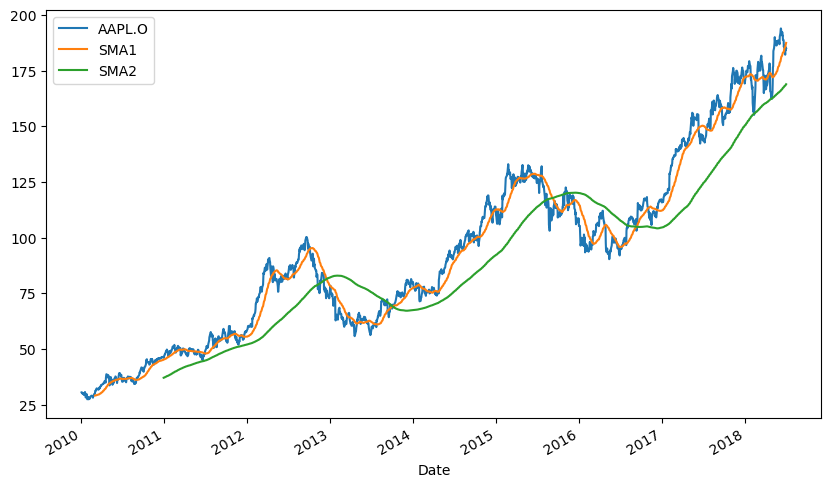

In [18]:
data[[sym,'SMA1','SMA2']].plot(figsize=(10,6))

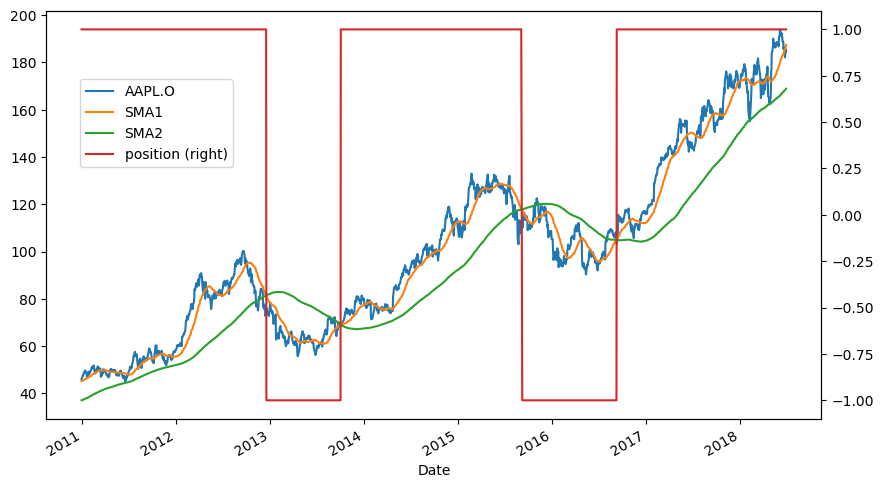

In [21]:
data.dropna(inplace=True)
data['position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)
ax = data[[sym,'SMA1','SMA2','position']]\
    .plot(figsize=(10,6),
          secondary_y='position')
ax.get_legend().set_bbox_to_anchor((0.25,0.85))

3:

In [22]:
file_path = 'source/Chap_7/tr_eikon_eod_data.csv'
raw = pd.read_csv(file_path,index_col=0,parse_dates=True)
data = raw[['.SPX','.VIX']].dropna()
data.tail()

,.SPX,.VIX
Date,,
2018-06-25,2717.07,17.33
2018-06-26,2723.06,15.92
2018-06-27,2699.63,17.91
2018-06-28,2716.31,16.85
2018-06-29,2718.37,16.09


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

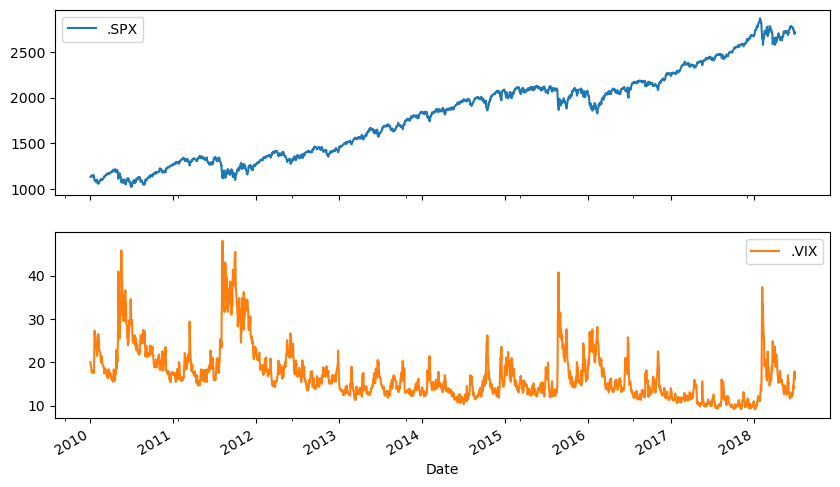

In [23]:
data.plot(subplots=True,figsize=(10,6))

<Axes: xlabel='Date'>

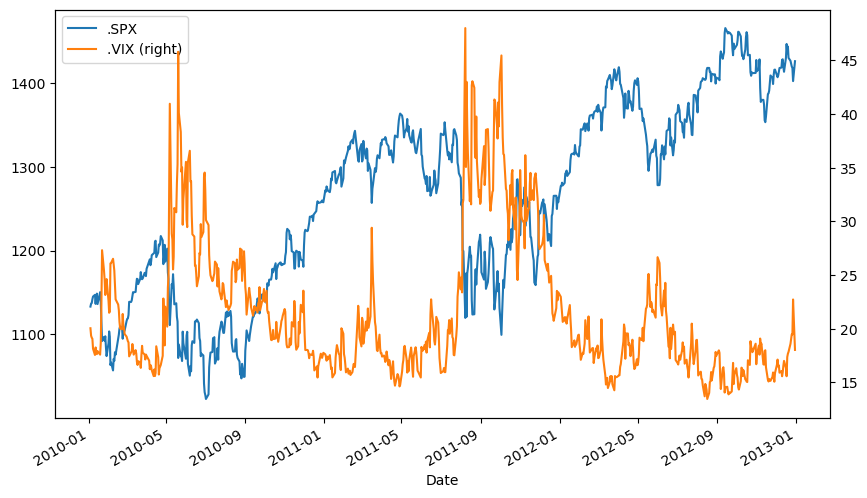

In [24]:
data.loc[:'2012-12-31'].plot(secondary_y='.VIX',figsize=(10,6))

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

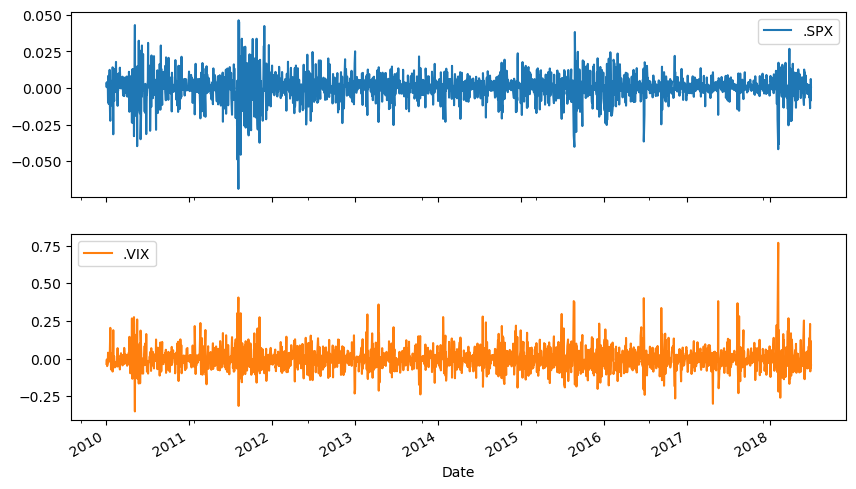

In [28]:
rets = np.log(data / data.shift(1))
# rets.head()
rets.dropna(inplace=True)
rets.plot(subplots=True, figsize=(10,6))

array([[<Axes: xlabel='.SPX', ylabel='.SPX'>,
        <Axes: xlabel='.VIX', ylabel='.SPX'>],
       [<Axes: xlabel='.SPX', ylabel='.VIX'>,
        <Axes: xlabel='.VIX', ylabel='.VIX'>]], dtype=object)

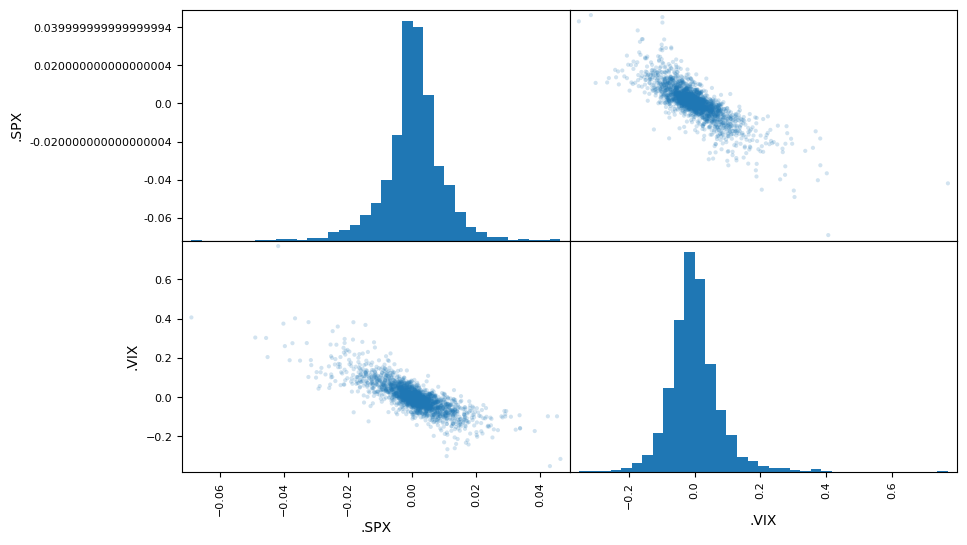

In [29]:
pd.plotting.scatter_matrix(rets,
                           alpha=0.2,
                           diagonal='hist',
                           hist_kwds={'bins':35},
                           figsize=(10,6))

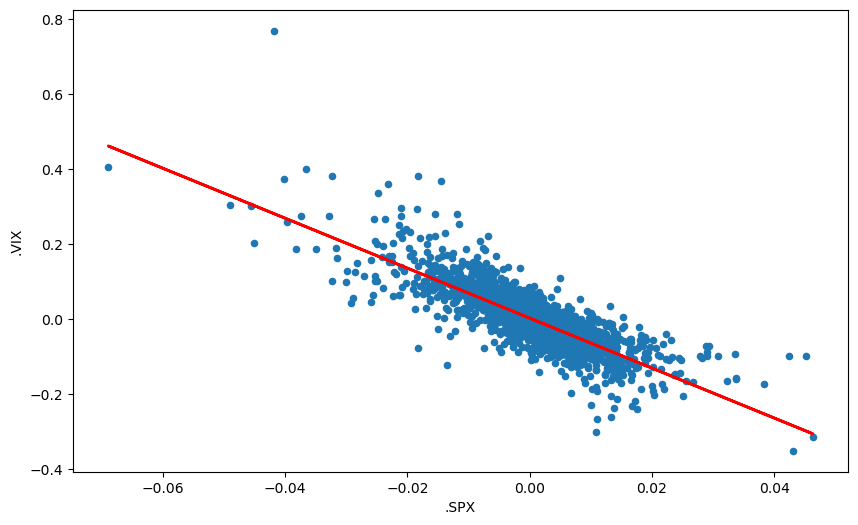

In [32]:
reg = np.polyfit(rets['.SPX'],rets['.VIX'],deg=1)
ax = rets.plot(kind='scatter',x='.SPX',y='.VIX',figsize=(10,6))
ax.plot(rets['.SPX'],np.polyval(reg,rets['.SPX']),'r',lw=2)

In [33]:
rets.corr()

,.SPX,.VIX
.SPX,1.000000,-0.804382
.VIX,-0.804382,1.000000


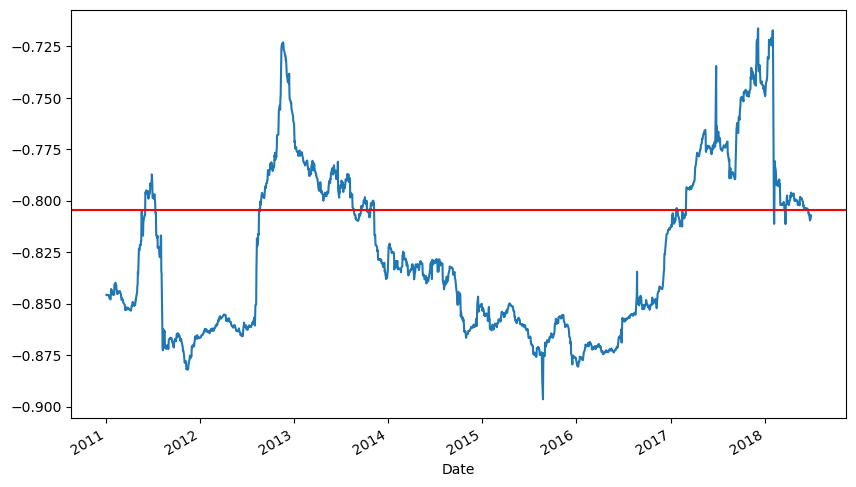

In [40]:
ax = rets['.SPX'].rolling(window=252).corr(
    rets['.VIX']).plot(figsize=(10,6))
ax.axhline(rets.corr().iloc[0,1],c='r')

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 461357 entries, 2018-06-29 00:00:00.082000 to 2018-06-29 20:59:00.607000
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Bid     461357 non-null  float64
 1   Ask     461357 non-null  float64
dtypes: float64(2)
memory usage: 10.6 MB


<Axes: >

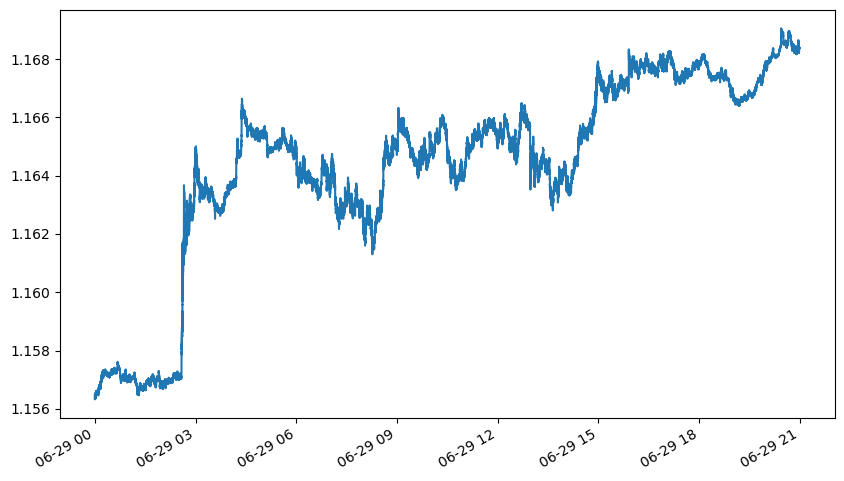

In [51]:
file_path = 'source/chap_7/fxcm_eur_usd_tick_data.csv'
tick = pd.read_csv(file_path,index_col=0,parse_dates=True)
tick.info()
tick['Mid'] = tick.mean(axis=1)
tick['Mid'].plot(figsize=(10,6))

In [54]:
tick_resam = tick.resample(rule='5min',label='right').last()
tick_resam.head()

,Bid,Ask,Mid
2018-06-29 00:05:00,1.15649,1.15651,1.156500
2018-06-29 00:10:00,1.15671,1.15672,1.156715
2018-06-29 00:15:00,1.15725,1.15727,1.157260
2018-06-29 00:20:00,1.15720,1.15722,1.157210
2018-06-29 00:25:00,1.15711,1.15712,1.157115


<Axes: >

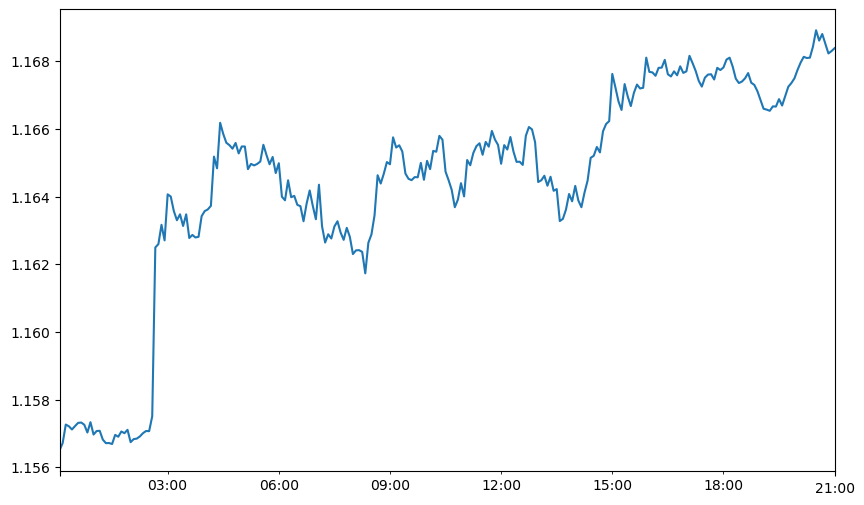

In [55]:
tick_resam['Mid'].plot(figsize=(10,6))